In [ ]:
import xarray as xr
import matplotlib.pyplot as plt
from scripts.mask_convert import mask_netcdf

In [2]:


UTCI_LEVELS = {
    0: (float("-inf"), -40, "Estrés por frío extremo"),
    1: (-40, -27, "Estrés por frío muy fuerte"),
    2: (-27, -13, "Estrés por frío fuerte"),
    3: (-13, 0, "Estrés por frío moderado"),
    4: (0, 9, "Estrés por frío ligero"),
    5: (9, 26, "Sin estrés térmico"),
    6: (26, 32, "Estrés por calor moderado"),
    7: (32, 38, "Estrés por calor fuerte"),
    8: (38, 46, "Estrés por calor muy fuerte"),
    9: (46, float("inf"), "Estrés por calor extremo"),
}


def calculate_thermal_stress_percentage(
    netcdf_path,
    shapefile_path,
    levels=UTCI_LEVELS,
    dim="time",
):
    """
    Enmascara un NetCDF de UTCI con un shapefile y calcula, para cada punto
    espacial, el porcentaje de tiempo que el UTCI cae en cada categoría de
    estrés térmico.

    Parameters
    ----------
    netcdf_path : str
        Ruta al archivo NetCDF con los datos de UTCI (en grados Celsius).
    shapefile_path : str
        Ruta al shapefile/gpkg usado para enmascarar la zona de interés.
    levels : dict
        Diccionario {codigo: (lim_inf, lim_sup, etiqueta)} con los límites
        de cada categoría de estrés térmico. Por defecto usa UTCI_LEVELS.
    dim : str
        Nombre de la dimensión sobre la que se calculan los porcentajes
        (normalmente "time").

    Returns
    -------
    xr.DataArray o xr.Dataset
        Con una nueva dimensión "category" (y su coordenada
        "category_label") y las dimensiones espaciales originales. Los
        valores son porcentajes (0-100).
    """
    utci = mask_netcdf(
        netcdf_path=netcdf_path,
        shapefile_path=shapefile_path,
    )

    categories = xr.full_like(utci, float("nan"))

    for category, (lim_inf, lim_sup, _) in levels.items():
        mask = (utci > lim_inf) & (utci <= lim_sup)
        categories = xr.where(mask, category, categories)

    categories = categories.astype("float32")

    valid_count = categories.notnull().sum(dim)

    counts = xr.concat(
        [(categories == category).sum(dim) for category in levels],
        dim="category",
    )
    counts = counts.assign_coords(category=list(levels.keys()))

    stress_percentage = counts / valid_count * 100

    labels = [info[2] for info in levels.values()]
    stress_percentage = stress_percentage.assign_coords(
        category_label=("category", labels)
    )

    return stress_percentage

In [ ]:
utci = calculate_thermal_stress_percentage(
    netcdf_path="../data/001_raw/ECMWF_utci_2022_mexico_anual.nc",
    shapefile_path="../data/001_raw/mexico_mask.gpkg",
)
utci

<xarray.Dataset> Size: 822kB
Dimensions:         (lon: 133, lat: 77, category: 10)
Coordinates:
  * lon             (lon) float64 1kB -119.0 -118.8 -118.5 ... -86.25 -86.0
  * lat             (lat) float64 616B 33.0 32.75 32.5 32.25 ... 14.5 14.25 14.0
  * category        (category) int64 80B 0 1 2 3 4 5 6 7 8 9
    category_label  (category) <U27 1kB 'Estrés por frío extremo' ... 'Estrés...
    spatial_ref     int64 8B 0
Data variables:
    utci            (category, lat, lon) float64 819kB nan nan nan ... nan nan

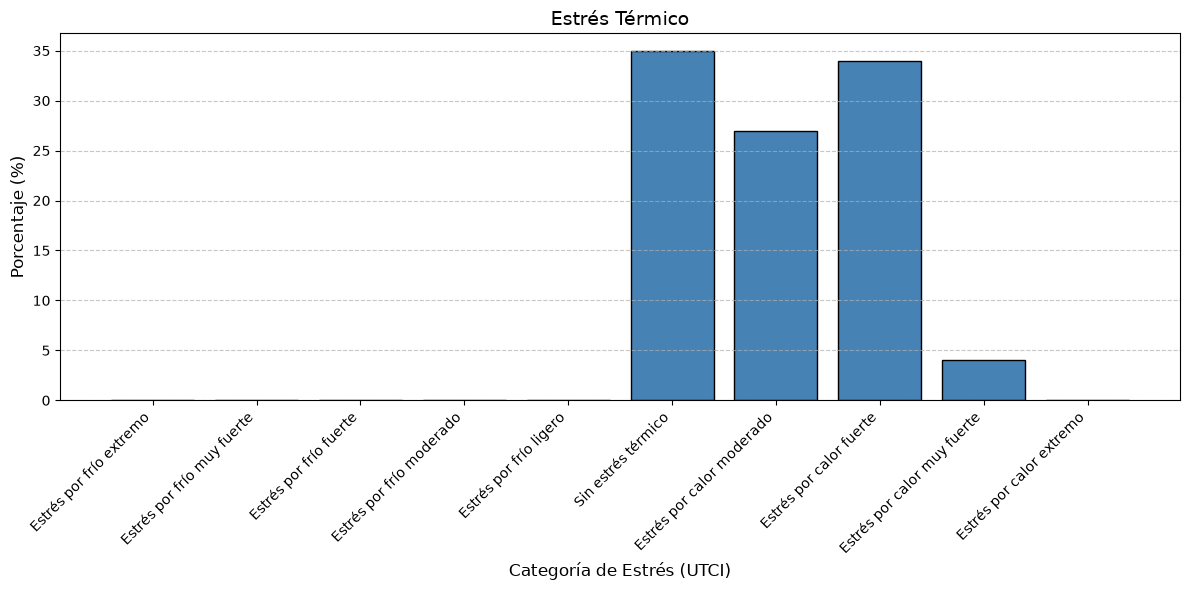

In [4]:
punto_prueba = utci.sel(lat=14.75, lon=-92.25, method="nearest") 	

fig, ax = plt.subplots(figsize=(12, 6))  

ax.bar(
    punto_prueba["category_label"].values,  
    punto_prueba["utci"].values,           
    color="steelblue", 
    edgecolor="black"
)

ax.set_title("Estrés Térmico", fontsize=14)
ax.set_ylabel("Porcentaje (%)", fontsize=12)
ax.set_xlabel("Categoría de Estrés (UTCI)", fontsize=12)

plt.xticks(rotation=45, ha="right", fontsize=10)

ax.grid(axis="y", linestyle="--", alpha=0.7)  

plt.tight_layout() 
plt.show()
